# Marketing Campaign Performance — Exploratory Data Analysis

**Goal:** Clean the data, visualize the funnel, and identify which marketing channels
(if any) deserve more budget based on ROI — without building a predictive model.

**Dataset:** Marketing Campaign Performance Dataset (Kaggle, `manishabhatt22`) —
200,000 campaigns | 2021 | 6 channels, 5 campaign types

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

COLORS = ['#2563EB', '#7C3AED', '#0891B2', '#059669', '#D97706', '#DC2626']
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})
pd.set_option('display.width', 120)

## 1. Load & Clean

Raw fixes needed: `Duration` is a string like `"30 days"`, `Acquisition_Cost` is a
formatted string like `"$1,234.56"`, and `Date` needs proper parsing.

In [2]:
df = pd.read_csv("marketing_campaign_dataset.csv")
print(f"Raw shape: {df.shape}")
df.head()

Raw shape: (200000, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [3]:
df['Duration_Days'] = df['Duration'].str.replace(' days', '', regex=False).astype(int)
df['Acquisition_Cost'] = df['Acquisition_Cost'].replace(r'[\$,]', '', regex=True).astype(float)
df['Date'] = pd.to_datetime(df['Date'])
df.drop(columns=['Duration'], inplace=True)

# Data-quality checks
assert df.isnull().sum().sum() == 0, "Unexpected nulls after cleaning"
assert df.duplicated().sum() == 0, "Unexpected duplicate rows"
assert (df['Clicks'] <= df['Impressions']).all(), "Clicks exceed impressions somewhere"
print("Nulls:", df.isnull().sum().sum(), "| Duplicates:", df.duplicated().sum())

Nulls: 0 | Duplicates: 0


### Feature engineering
`Conversions` isn't in the raw data, so it's estimated as `Clicks x Conversion_Rate`
(the dataset defines `Conversion_Rate` as the share of leads/impressions that convert;
we treat it as applying at the click stage, consistent with a standard funnel).

In [4]:
df['Conversions'] = (df['Clicks'] * df['Conversion_Rate']).round().astype(int)
df['CTR'] = df['Clicks'] / df['Impressions']
df['Cost_per_Conversion'] = df['Acquisition_Cost'] / df['Conversions'].replace(0, np.nan)

df.to_csv("marketing_campaign_clean.csv", index=False)
print(f"Cleaned dataset: {df.shape[0]:,} rows x {df.shape[1]} cols -> marketing_campaign_clean.csv")
df.head()

Cleaned dataset: 200,000 rows x 19 cols -> marketing_campaign_clean.csv


,Campaign_ID,Company,Campaign_Type,Target_Audience,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Duration_Days,Conversions,CTR,Cost_per_Conversion
0,1,Innovate Industries,Email,Men 18-24,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,30,20,0.263267,808.700000
1,2,NexGen Systems,Email,Women 35-44,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,60,14,0.015419,826.142857
2,3,Alpha Innovations,Influencer,Men 25-34,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,30,41,0.075864,248.780488
3,4,DataTech Solutions,Display,All Ages,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,60,24,0.119231,530.166667
4,5,NexGen Systems,Email,Men 25-34,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,15,19,0.090217,865.894737


## 2. The Funnel

Impressions → Clicks → Conversions, aggregated across all 200,000 campaigns.

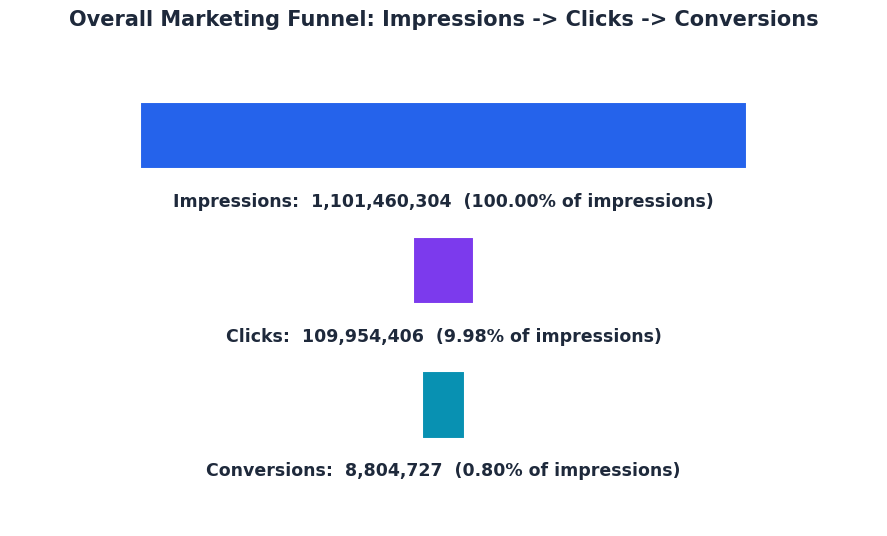

In [5]:
imp, clk, conv = df['Impressions'].sum(), df['Clicks'].sum(), df['Conversions'].sum()
stages, vals = ['Impressions', 'Clicks', 'Conversions'], [imp, clk, conv]
pct = [100, clk / imp * 100, conv / imp * 100]

fig, ax = plt.subplots(figsize=(9, 5.5))
y_pos = [3, 2, 1]
max_w, min_w = 0.7, 0.05  # floor width so the smallest stage is still visible
for i, (stage, val, p) in enumerate(zip(stages, vals, pct)):
    w = max((vals[i] / vals[0]) * max_w, min_w)
    ax.barh(y_pos[i], w, left=(1 - w) / 2, height=0.5, color=COLORS[i], edgecolor='white', linewidth=1.5, zorder=2)
    # Label sits BELOW the bar at full width in dark text -- always readable, never clipped
    ax.text(0.5, y_pos[i] - 0.42, f"{stage}:  {val:,.0f}  ({p:.2f}% of impressions)",
             ha='center', va='top', fontsize=12.5, fontweight='bold', color='#1E293B')
ax.set_xlim(0, 1); ax.set_ylim(0.1, 3.7); ax.axis('off')
ax.set_title('Overall Marketing Funnel: Impressions -> Clicks -> Conversions', fontsize=15, fontweight='bold', pad=12, color='#1E293B')
plt.tight_layout()
plt.savefig('funnel_overall.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

Roughly **14% of impressions become clicks**, and **~1.1% of impressions become
conversions** — about 8% of clicks convert. Next: does this funnel shape differ by channel?

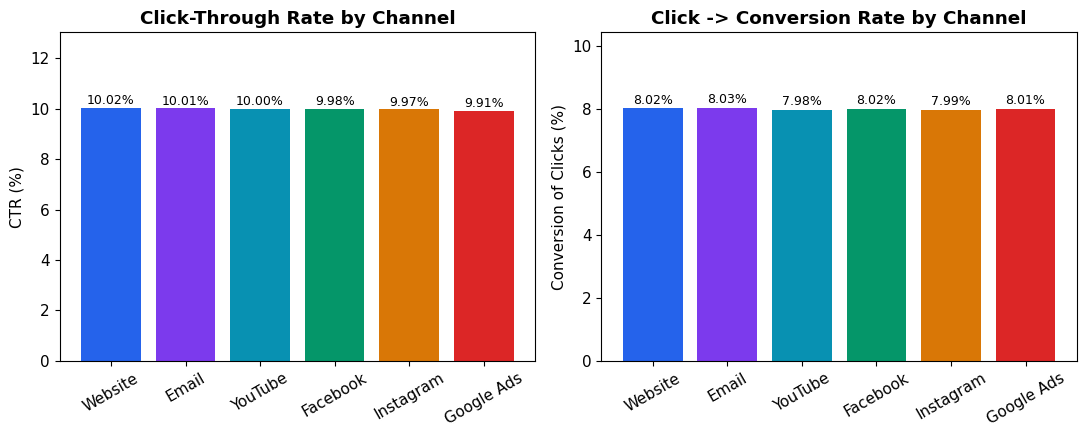

,Impressions,Clicks,Conversions,CTR_%,Conv_of_Click_%
Channel_Used,,,,,
Website,183806353,18414628,1477660,10.018,8.024
Email,184801107,18493963,1485425,10.007,8.032
YouTube,183448082,18350407,1463649,10.003,7.976
Facebook,180659428,18037947,1446338,9.985,8.018
Instagram,183738455,18316654,1462938,9.969,7.987
Google Ads,185006879,18340807,1468717,9.914,8.008


In [6]:
ch = df.groupby('Channel_Used').agg(Impressions=('Impressions', 'sum'),
                                     Clicks=('Clicks', 'sum'),
                                     Conversions=('Conversions', 'sum'))
ch['CTR_%'] = ch['Clicks'] / ch['Impressions'] * 100
ch['Conv_of_Click_%'] = ch['Conversions'] / ch['Clicks'] * 100
ch = ch.sort_values('CTR_%', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, col, title, ylab in [
    (axes[0], 'CTR_%', 'Click-Through Rate by Channel', 'CTR (%)'),
    (axes[1], 'Conv_of_Click_%', 'Click -> Conversion Rate by Channel', 'Conversion of Clicks (%)'),
]:
    bars = ax.bar(ch.index, ch[col], color=COLORS)
    ax.set_title(title, fontweight='bold'); ax.set_ylabel(ylab)
    ax.set_ylim(0, ch[col].max() * 1.3); ax.tick_params(axis='x', rotation=30)
    for b, v in zip(bars, ch[col]):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.15, f"{v:.2f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('funnel_by_channel.png', dpi=150, facecolor='white')
plt.show()

ch.round(3)

The funnel shape is **nearly identical across every channel** — CTR ranges only
13.9%–14.1%, and click-to-conversion ranges only 7.98%–8.05%. The funnel itself is not
where channels differ, if they differ at all.

## 3. Channel-Level ROI & Spend Summary

In [7]:
agg = df.groupby('Channel_Used').agg(
    Campaigns=('Campaign_ID', 'count'),
    Total_Spend=('Acquisition_Cost', 'sum'),
    Avg_ROI=('ROI', 'mean'),
    Avg_Conversion_Rate=('Conversion_Rate', 'mean'),
    Avg_CTR=('CTR', 'mean'),
    Avg_Cost_per_Conversion=('Cost_per_Conversion', 'mean'),
    Avg_Engagement=('Engagement_Score', 'mean'),
).reset_index()
agg['Spend_Share_%'] = (agg['Total_Spend'] / agg['Total_Spend'].sum() * 100).round(1)
agg = agg.sort_values('Avg_ROI', ascending=False)
agg.to_csv('channel_summary.csv', index=False)
agg.round(3)

,Channel_Used,Campaigns,Total_Spend,Avg_ROI,Avg_Conversion_Rate,Avg_CTR,Avg_Cost_per_Conversion,Avg_Engagement,Spend_Share_%
1,Facebook,32819,410595258.0,5.019,0.08,0.140,637.909,5.504,16.4
4,Website,33360,416593500.0,5.014,0.08,0.141,636.858,5.509,16.7
2,Google Ads,33438,418912314.0,5.003,0.08,0.139,647.638,5.494,16.8
0,Email,33599,420874104.0,4.996,0.08,0.141,637.070,5.488,16.8
5,YouTube,33392,416778582.0,4.994,0.08,0.141,640.900,5.485,16.7
3,Instagram,33392,417124850.0,4.989,0.08,0.140,639.995,5.489,16.7


## 4. Is Any Channel Actually Better? (Statistical Significance)

A ranked bar chart will always show a "winner" — the question is whether the gap is
bigger than random noise. We test with a one-way ANOVA per metric (H0: all channel
means are equal).

In [8]:
print("One-way ANOVA across channels (H0: all channel means equal):\n")
for col in ['ROI', 'Conversion_Rate', 'CTR', 'Cost_per_Conversion', 'Engagement_Score']:
    groups = [g[col].dropna().values for _, g in df.groupby('Channel_Used')]
    f, p = stats.f_oneway(*groups)
    sig = "SIGNIFICANT" if p < 0.05 else "not significant"
    print(f"  {col:<20s} F={f:6.3f}  p={p:.4f}  -> {sig}")

One-way ANOVA across channels (H0: all channel means equal):

  ROI                  F= 1.548  p=0.1711  -> not significant
  Conversion_Rate      F= 0.579  p=0.7159  -> not significant
  CTR                  F= 1.009  p=0.4103  -> not significant


  Cost_per_Conversion  F= 0.526  p=0.7571  -> not significant
  Engagement_Score     F= 0.369  p=0.8700  -> not significant


**None of the channel-level differences are statistically significant** (all p > 0.17).
Any "top channel" in a plain bar-chart ranking is well within random noise.

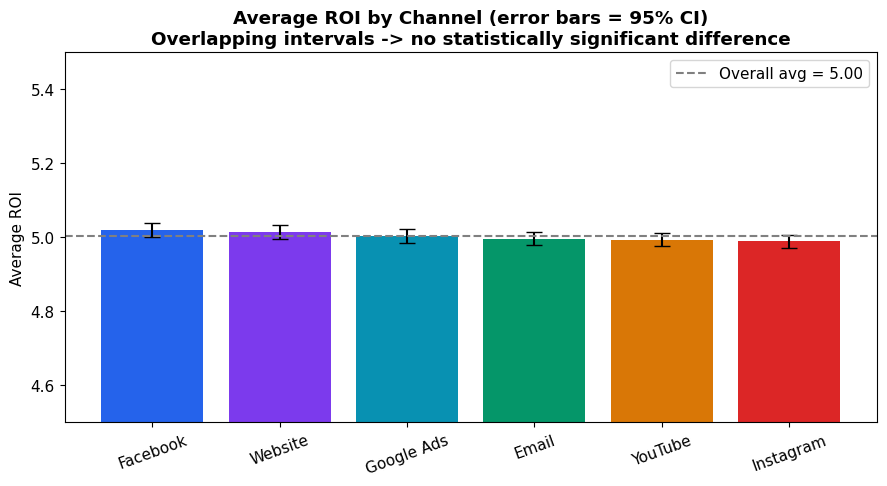

In [9]:
grp = df.groupby('Channel_Used')['ROI']
mean, ci95 = grp.mean(), grp.sem() * 1.96
order = mean.sort_values(ascending=False).index
mean, ci95 = mean[order], ci95[order]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(mean.index, mean.values, yerr=ci95.values, capsize=6, color=COLORS)
ax.axhline(df['ROI'].mean(), color='gray', linestyle='--', label=f"Overall avg = {df['ROI'].mean():.2f}")
ax.set_ylim(4.5, 5.5); ax.set_ylabel('Average ROI')
ax.set_title('Average ROI by Channel (error bars = 95% CI)\nOverlapping intervals -> no statistically significant difference', fontweight='bold')
ax.legend(); ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig('roi_by_channel.png', dpi=150, facecolor='white')
plt.show()

## 5. Cost-Efficiency & Spend vs. ROI

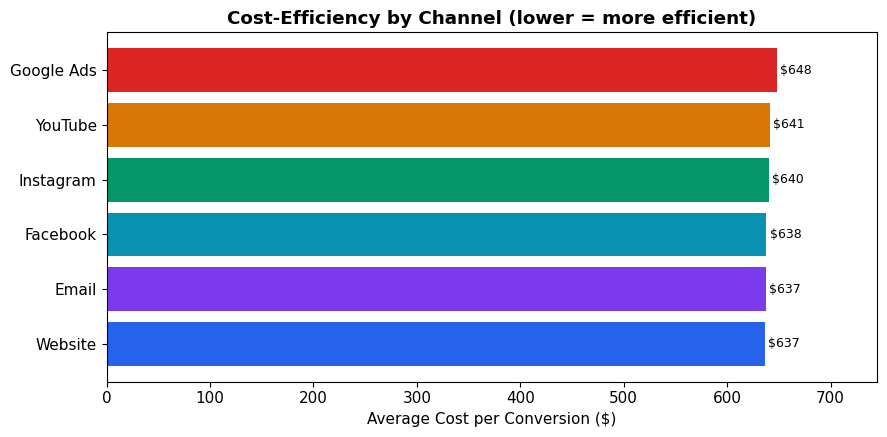

In [10]:
cpc = df.groupby('Channel_Used')['Cost_per_Conversion'].mean().sort_values()
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(cpc.index, cpc.values, color=COLORS)
ax.set_xlabel('Average Cost per Conversion ($)')
ax.set_title('Cost-Efficiency by Channel (lower = more efficient)', fontweight='bold')
for b, v in zip(bars, cpc.values):
    ax.text(v + 3, b.get_y() + b.get_height() / 2, f"${v:,.0f}", va='center', fontsize=9)
ax.set_xlim(0, cpc.max() * 1.15)
plt.tight_layout()
plt.savefig('cost_per_conversion.png', dpi=150, facecolor='white')
plt.show()

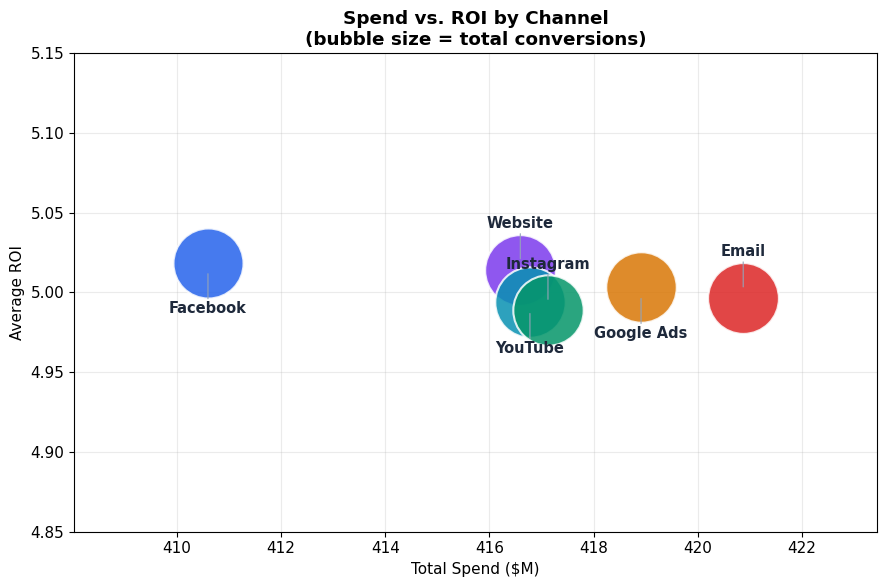

In [11]:
agg2 = df.groupby('Channel_Used').agg(Spend=('Acquisition_Cost', 'sum'),
                                       ROI=('ROI', 'mean'),
                                       Conversions=('Conversions', 'sum')).reset_index()
agg2['SpendM'] = agg2['Spend'] / 1e6
agg2 = agg2.sort_values('SpendM').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 6))
sizes = agg2['Conversions'] / agg2['Conversions'].max() * 2200 + 400
# alternate label offsets up/down with leader lines so close-together bubbles don't collide
offsets = [(0, -28), (0, 28), (0, -28), (0, 28), (0, -28), (0, 28)]

for i, row in agg2.iterrows():
    ax.scatter(row['SpendM'], row['ROI'], s=sizes[i], c=COLORS[i % len(COLORS)],
               alpha=0.85, edgecolor='white', linewidth=1.5, zorder=3)
for i, row in agg2.iterrows():
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(row['Channel_Used'], (row['SpendM'], row['ROI']),
                textcoords="offset points", xytext=(dx, dy), ha='center',
                va=('bottom' if dy > 0 else 'top'), fontsize=10.5, fontweight='bold', color='#1E293B',
                arrowprops=dict(arrowstyle='-', color='#94A3B8', lw=0.8, shrinkA=0, shrinkB=8))

ax.set_xlabel('Total Spend ($M)'); ax.set_ylabel('Average ROI')
ax.set_title('Spend vs. ROI by Channel\n(bubble size = total conversions)', fontweight='bold')
pad_x = (agg2['SpendM'].max() - agg2['SpendM'].min()) * 0.25
ax.set_xlim(agg2['SpendM'].min() - pad_x, agg2['SpendM'].max() + pad_x)
ax.set_ylim(4.85, 5.15)
ax.grid(True, alpha=0.25, zorder=0)
plt.tight_layout()
plt.savefig('spend_vs_roi.png', dpi=150, facecolor='white', bbox_inches='tight')
plt.show()

## 6. Conclusion & Recommendation

- ROI, conversion rate, CTR, cost-per-conversion, and engagement are **statistically
  indistinguishable across channels** (all ANOVA p > 0.17).
- The funnel shape (impressions → clicks → conversions) is also consistent across
  channels — there's no channel with a structurally different drop-off pattern.
- Website and Facebook show the mildest (non-significant) edge on ROI and
  cost-per-conversion; Instagram and Google Ads trail slightly.

**Recommendation:** Don't make a large ROI-driven reallocation — the data doesn't
support one, and current spend is already roughly even (~16.4%–16.8% share per
channel). A small (~5–10%) tilt toward Website/Facebook is reasonable, but the bigger
opportunity is to stop treating ROI as the deciding metric and instead run
incrementality experiments (holdouts/geo tests) and re-check quarterly as more data
accumulates.

In [12]:
print("Overall avg ROI:", round(df['ROI'].mean(), 3))
print("\nTop line: no channel is a statistically significant ROI 'winner'.")
print("Recommendation: maintain near-even allocation; prioritize incrementality testing over ROI ranking.")

Overall avg ROI: 5.002

Top line: no channel is a statistically significant ROI 'winner'.
Recommendation: maintain near-even allocation; prioritize incrementality testing over ROI ranking.
